In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
CSV_PATH = "archive/data.csv"
IMAGE_DIR = "archive/image"

df = pd.read_csv(CSV_PATH)
image_column = df.columns[0]
df["image_path"] = df[image_column].astype(str).apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpeg")
)
df = df[df["image_path"].apply(os.path.exists)]
print("Total valid samples:", len(df))

Total valid samples: 1512


In [39]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["label_encoded"] = encoder.fit_transform(df["classes"])
print("Classes:", encoder.classes_)

Classes: ['bumper_dent' 'bumper_scratch' 'door_dent' 'door_scratch' 'glass_shatter'
 'head_lamp' 'tail_lamp' 'unknown']


In [40]:
IMG_SIZE = 224
images = []
labels = []

for i, row in df.iterrows():
    img = cv2.imread(row["image_path"])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    images.append(img)
    labels.append(row["classes"])

X = np.array(images)
y = np.array(labels)
print("Data Shape:", X.shape)

Data Shape: (1512, 224, 224, 3)


In [41]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
num_classes = len(np.unique(y))

In [42]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1209, 224, 224, 3)
Validation: (151, 224, 224, 3)
Test: (152, 224, 224, 3)


In [43]:
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [44]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [45]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def build_cnn12_best():
    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D())

    # Block 2
    model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D())

    # Block 3
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D())

    # Block 4
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D())

    # Block 5 (NEW - improves accuracy)
    model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D())

    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    return model

In [49]:
model = build_cnn12_best()   # or cnn15_best

model.compile(
    optimizer=Adam(learning_rate=0.00003),  # 🔥 VERY IMPORTANT
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=60, 
    callbacks=[early_stop],
    verbose=1
)

c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
 7/38 ━━━━━━━━━━━━━━━━━━━━ 1:13 2s/step - accuracy: 0.1041 - loss: 2.4580

KeyboardInterrupt: 

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.1154 - loss: 2.0855

Model Evaluation
----------------------------
Test Loss     : 2.0884
Test Accuracy : 0.1053
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step

Overall Metrics
----------------------------
Accuracy  : 0.1053
Precision : 0.0111
Recall    : 0.1053
F1 Score  : 0.0201

Classification Report
----------------------------
                precision    recall  f1-score   support

   bumper_dent       0.00      0.00      0.00        13
bumper_scratch       0.00      0.00      0.00         8
     door_dent       0.00      0.00      0.00        20
  door_scratch       0.11      1.00      0.19        16
 glass_shatter       0.00      0.00      0.00        13
     head_lamp       0.00      0.00      0.00        13
     tail_lamp       0.00      0.00      0.00        14
       unknown       0.00      0.00      0.00        55

      accuracy                           0.11       152
     macro avg       0.01      0.12      0.02       152
  w

c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

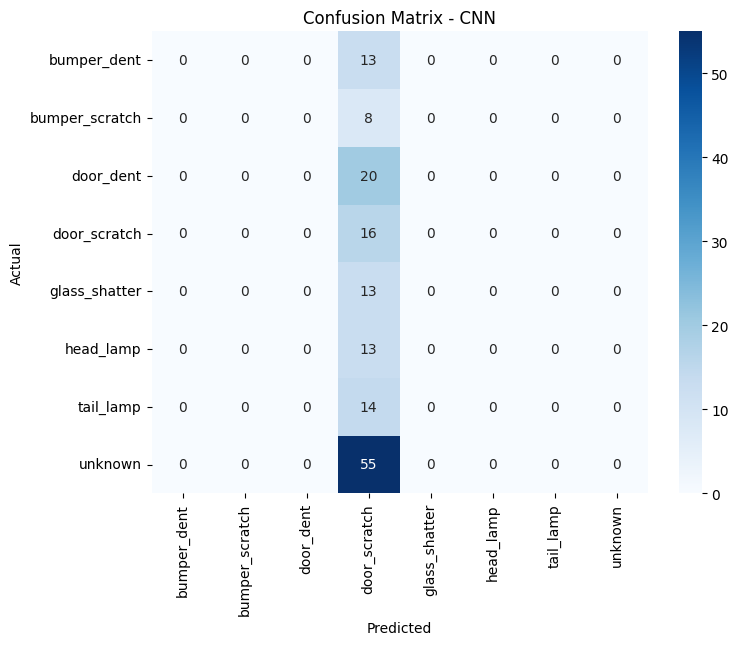

In [48]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nModel Evaluation")
print("----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


# =========================
# 12. METRICS
# =========================
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

y_true = encoder.inverse_transform(y_test)
y_pred = encoder.inverse_transform(pred_classes)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\nOverall Metrics")
print("----------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# =========================
# 13. CLASSIFICATION REPORT
# =========================
print("\nClassification Report")
print("----------------------------")
print(classification_report(y_true, y_pred))


# =========================
# 14. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
def build_cnn15():
    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)))
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [32]:
model = build_cnn12_strong()  # or cnn15

model.compile(
    optimizer=Adam(learning_rate=0.00005),  # 🔥 LOWER LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=50,   # 🔥 increase epochs
    verbose=1
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.3347 - loss: 2.0541 - val_accuracy: 0.1258 - val_loss: 2.1246
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.3710 - loss: 1.7671 - val_accuracy: 0.0993 - val_loss: 2.2237
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.3788 - loss: 1.7265 - val_accuracy: 0.0993 - val_loss: 2.3612
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.4818 - loss: 1.5069 - val_accuracy: 0.0993 - val_loss: 2.5658
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.5173 - loss: 1.4524 - val_accuracy: 0.0993 - val_loss: 2.6838
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.4899 - loss: 1.4819 - val_accuracy: 0.0993 - val_loss: 2.9024
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.5049 - loss: 1.3886 - val_accuracy: 0.0993 - val_loss: 3.0326
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.5079 - loss: 1.3710 - val_accuracy: 0.0927 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.6228 - loss: 1.2978

Model Evaluation
----------------------------
Test Loss     : 1.2932
Test Accuracy : 0.6184
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step

Overall Evaluation Metrics
----------------------------
Accuracy  : 0.6184
Precision : 0.6080
Recall    : 0.6184
F1 Score  : 0.5938

Detailed Classification Report
----------------------------
                precision    recall  f1-score   support

   bumper_dent       0.40      0.31      0.35        13
bumper_scratch       0.33      0.12      0.18         8
     door_dent       0.56      0.50      0.53        20
  door_scratch       0.47      0.56      0.51        16
 glass_shatter       0.83      0.38      0.53        13
     head_lamp       0.62      0.38      0.48        13
     tail_lamp       0.64      0.64      0.64        14
       unknown       0.69      0.93      0.79        55

      accuracy                           0.62       152
     macro avg       0.57      0.48    

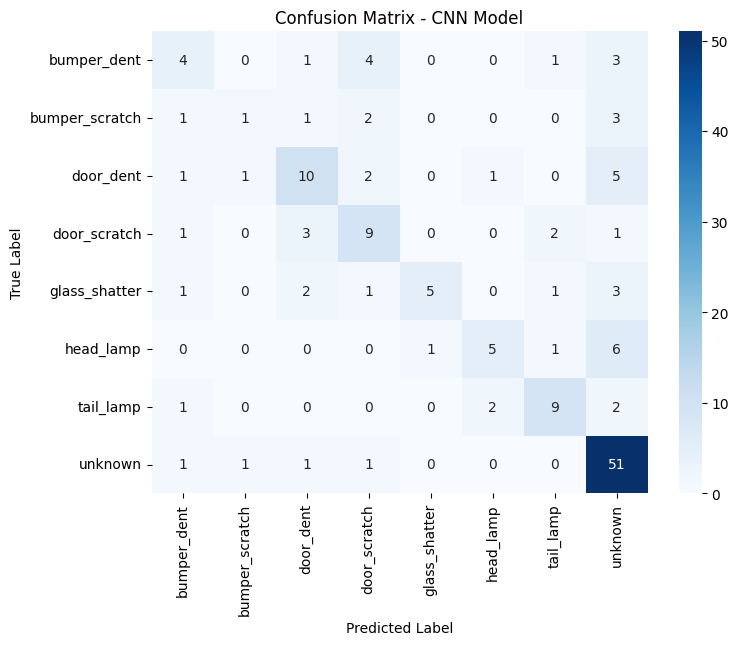

In [35]:
# =========================
# EVALUATION
# =========================

test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nModel Evaluation")
print("----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


# =========================
# PREDICTIONS
# =========================

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

# Convert to actual labels
y_test_labels = encoder.inverse_transform(y_test)
pred_labels = encoder.inverse_transform(pred_classes)


# =========================
# METRICS
# =========================

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nOverall Evaluation Metrics")
print("----------------------------")

accuracy = accuracy_score(y_test_labels, pred_labels)
precision = precision_score(y_test_labels, pred_labels, average='weighted')
recall = recall_score(y_test_labels, pred_labels, average='weighted')
f1 = f1_score(y_test_labels, pred_labels, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# =========================
# CLASSIFICATION REPORT
# =========================

print("\nDetailed Classification Report")
print("----------------------------")
print(classification_report(y_test_labels, pred_labels))


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_labels, pred_labels)

print("\nConfusion Matrix")
print("----------------------------")
print(cm)


# =========================
# HEATMAP (WITH MODEL NAME)
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN Model")  # change name if needed

plt.show()

In [29]:
# Build model
model = build_cnn15() 

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping (optional but good)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=40,   # ✅ THIS WILL RUN
    callbacks=[early_stop],
    verbose=1
)

c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Bhanu Praneeth G\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.3214 - loss: 1.9654 - val_accuracy: 0.3642 - val_loss: 1.8334
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.3559 - loss: 1.8132 - val_accuracy: 0.3642 - val_loss: 1.7750
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.3875 - loss: 1.6969 - val_accuracy: 0.4040 - val_loss: 1.7081
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.4348 - loss: 1.6282 - val_accuracy: 0.4040 - val_loss: 1.6785
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.4191 - loss: 1.5976 - val_accuracy: 0.4106 - val_loss: 1.5898
Epoch 6/40
36/38 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.4465 - loss: 1.5384

KeyboardInterrupt: 

In [ ]:
# =========================
# EVALUATION
# =========================

test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("\nModel Evaluation")
print("----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


# =========================
# PREDICTIONS
# =========================

pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

# Convert to actual labels
y_test_labels = encoder.inverse_transform(y_test)
pred_labels = encoder.inverse_transform(pred_classes)


# =========================
# METRICS
# =========================

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nOverall Evaluation Metrics")
print("----------------------------")

accuracy = accuracy_score(y_test_labels, pred_labels)
precision = precision_score(y_test_labels, pred_labels, average='weighted')
recall = recall_score(y_test_labels, pred_labels, average='weighted')
f1 = f1_score(y_test_labels, pred_labels, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# =========================
# CLASSIFICATION REPORT
# =========================

print("\nDetailed Classification Report")
print("----------------------------")
print(classification_report(y_test_labels, pred_labels))


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test_labels, pred_labels)

print("\nConfusion Matrix")
print("----------------------------")
print(cm)


# =========================
# HEATMAP (WITH MODEL NAME)
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN Model")  # change name if needed

plt.show()